Customer is in company or not...
for example .. people using airtel switched to jio ...:
* Due to Prices.
* also jio started providing servies for better prices...
 #so they leaved airtel
..Airtel will say churned ana

In [2]:
pip install pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [7]:
df["TotalCharges"]= df["TotalCharges"].replace(" ","0")
df["TotalCharges"]= df["TotalCharges"].astype("float")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
#Descriptive analysis

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
#checking for duplicate values

In [13]:
df["customerID"].duplicated().sum()

np.int64(0)

In [14]:
def conv(values):
  if values==1:
    return "yes"
  else:
    return "no"

df['SeniorCitizen']=df['SeniorCitizen'].apply(conv)

converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

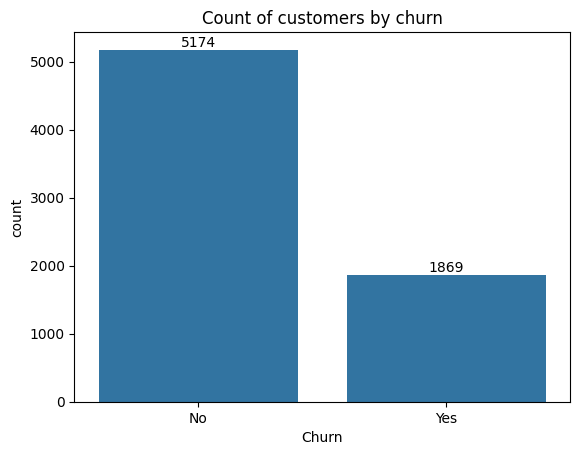

In [33]:
ax= sns.countplot(x='Churn', data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by churn")
plt.show()

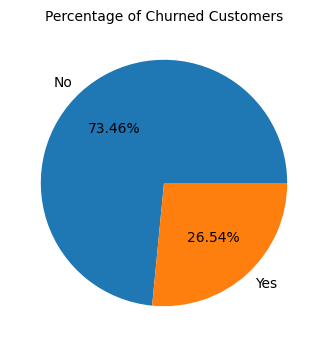

In [36]:
plt.figure(figsize=(4,4))
gb=df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels= gb.index, autopct="%1.2f%%")
plt.title("Percentage of Churned Customers", fontsize=10)
plt.show()


from the given pie chart we can conclude that 26.54% of our customers have churned out
not let's explore the reason behing it

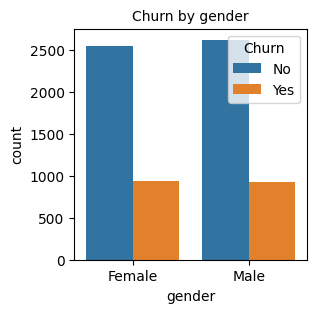

In [47]:
plt.figure(figsize=(3,3))
sns.countplot(x="gender", data=df, hue="Churn")
plt.title("Churn by gender", fontsize=10)
plt.show()

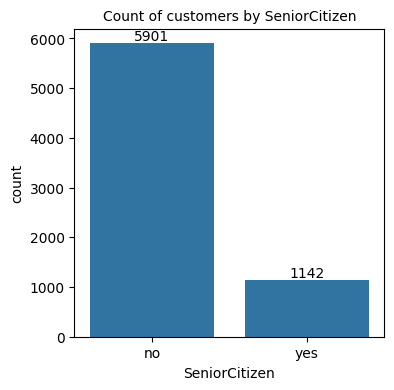

In [59]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x = "SeniorCitizen", data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by SeniorCitizen", fontsize=10)
plt.show()

comparative a greated percentage of people

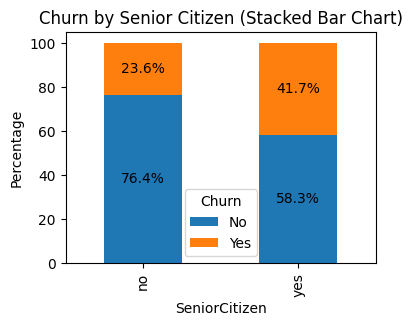

In [52]:

data = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

# Create stacked bar chart
ax = data.plot(kind="bar", stacked=True, figsize=(4,3))

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.title("Churn by Senior Citizen (Stacked Bar Chart)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

comparative a greater precentage of people in senior citizen category have churned

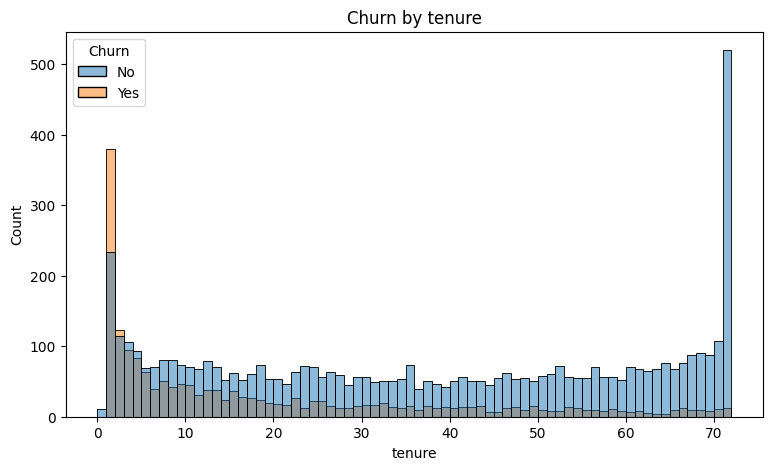

In [69]:
plt.figure(figsize=(9,5))
sns.histplot(x="tenure", data=df,bins=72,hue="Churn")
plt.title("Churn by tenure")
plt.show()

people who have used our services for a long time have stayed and people who have used our services for 1 or 2 months have churned

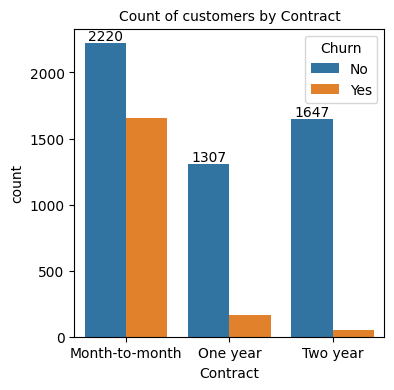

In [73]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x = "Contract", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Contract", fontsize=10)
plt.show()

People who have contract of month to month to churn then from those who have 1 or 2 years of contract

In [74]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

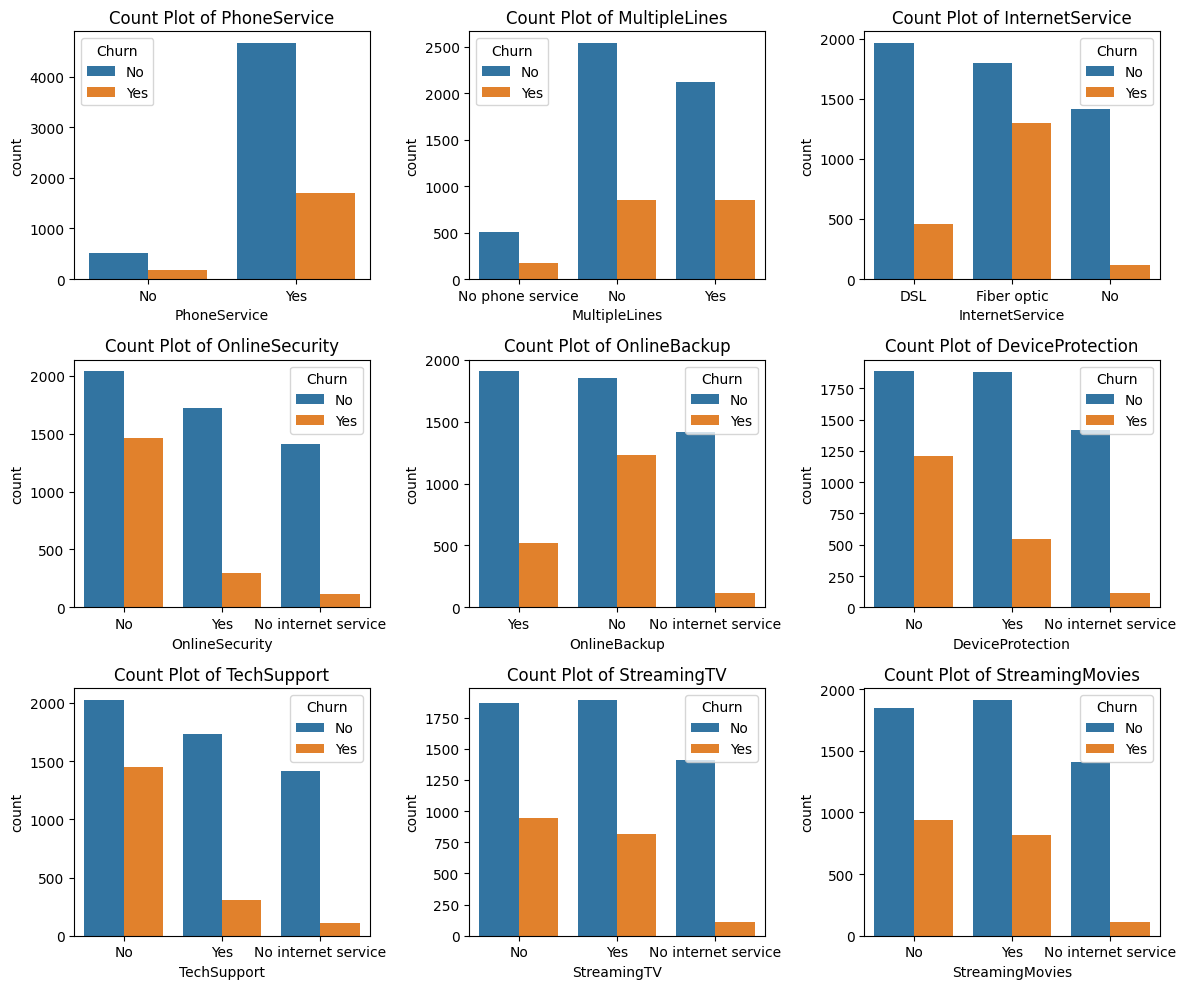

In [87]:
# List of categorical columns to visualize
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

# Loop through each column and corresponding subplot
for col, ax in zip(cols, axes.flatten()):

    # Create count plot with Churn as hue
    sns.countplot(data=df, x=col, hue="Churn", ax=ax)

    # Set title of each subplot
    ax.set_title(f"Count Plot of {col}")

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=360)


# Adjusting spacing between plots
plt.tight_layout()

# Display all subplots
plt.show()

* Customers with **Fiber Optic internet service** show the highest churn compared to DSL and those without internet service.
* Churn is significantly higher among customers who **do not have Online Security, Online Backup, Device Protection, or Tech Support**.
* Customers with **Phone Service, Multiple Lines, Streaming TV, and Streaming Movies** show relatively balanced distributions, indicating a weaker relationship with churn.
* Overall, **security and support-related services appear to have the strongest impact on customer retention**, while customers lacking these services are more likely to churn.


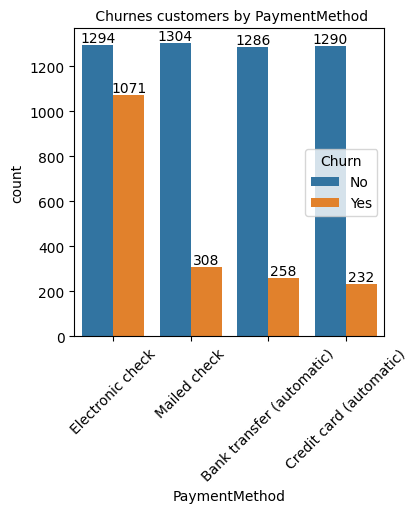

In [95]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x = "PaymentMethod", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title(" Churnes customers by PaymentMethod", fontsize=10)
plt.xticks(rotation=45)
plt.show()

Customer is likely to churn when he is using electronic check as a payment method.